### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

In [1]:
import os
from dotenv import load_dotenv

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="llama-3.1-8b-instant")

d:\2026-courses\agenticai\langraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict


In [3]:
class Section(BaseModel):
    name:str=Field(description="The name of the section")
    description:str=Field(description="A Brief overview of the main topics and conceps of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report")

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 


In [4]:
from langgraph.constants import Send

# Graph state
class State(TypedDict):
    topic:str
    sections:List[Section]
    completed_sections: Annotated[list, operator.add]
    final_report:str


    # Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

C:\Users\pc\AppData\Local\Temp\ipykernel_17940\3268442106.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send
d:\2026-courses\agenticai\langraph\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
# Nodes
def orchestrator(state:State):  
    """Orchestrator that generates a plan for the report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report sections: ", report_sections)
    return {
        "sections": report_sections.sections,
    }

    

In [7]:
def llm_call(state: WorkerState):
    """Worker writes a section of the report"""
    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {
        "completed_sections": [section.content],
    }

In [8]:
# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]



In [9]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

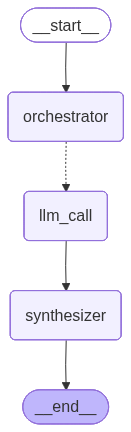

In [10]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)

orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [11]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report sections:  sections=[Section(name='Introduction to Agentic AI', description='Overview of agentic AI and its relevance to the report topic'), Section(name='Types of Agentic AI', description='Breakdown of various types of agentic AI and their characteristics'), Section(name='Benefits and Applications', description='Discussion of the benefits and applications of agentic AI'), Section(name='Challenges and Limitations', description=' Examination of the challenges and limitations of agentic AI'), Section(name='Future Developments and Implications', description='Discussion of the future developments and implications of agentic AI')]


**Introduction to Agentic AI**
================================

### Overview of Agentic AI

Agentic AI refers to a type of artificial intelligence (AI) that exhibits characteristics and behaviors similar to those of a human agent. This includes autonomy, self-awareness, decision-making, and the ability to interact with its environment in a proactive manner. Agentic AI is designed to perform tasks and achieve goals in a flexible and adaptable way, often relying on machine learning and deep learning techniques.

Agentic AI is relevant to this report because it represents a significant shift in the development of AI systems. Unlike traditional AI systems, which are typically designed to perform specific tasks in a predetermined manner, agentic AI is capable of learning and adapting to new situations and environments. This makes it an essential consideration for applications where uncertainty and unpredictability are high, such as in decision-making, navigation, and human-computer interaction.

### Key Characteristics of Agentic AI

* **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without direct human intervention.
* **Self-awareness**: Agentic AI systems have a sense of their own existence and can recognize themselves as entities within their environment.
* **Decision-making**: Agentic AI systems can make decisions based on their own goals, preferences, and values, rather than simply following pre-programmed rules.
* **Proactivity**: Agentic AI systems can take the initiative to interact with their environment and achieve their goals, rather than simply responding to external stimuli.

### Applications of Agentic AI

Agentic AI has a wide range of applications across various industries, including:

* **Decision-making**: Agentic AI can be used to support decision-making in complex and uncertain environments, such as finance, healthcare, and transportation.
* **Navigation**: Agentic AI can be used to develop autonomous vehicles and drones that can navigate complex environments and adapt to changing situations.
* **Human-computer interaction**: Agentic AI can be used to develop more intuitive and user-friendly interfaces that can learn and adapt to individual user preferences and behaviors.

### Conclusion

Agentic AI represents a significant advancement in the development of AI systems, offering a range of benefits and opportunities for applications in various industries. However, it also raises important questions and challenges related to the ethics, safety, and accountability of agentic AI systems. As we move forward with the development and deployment of agentic AI, it is essential to address these challenges and ensure that these systems are designed and used in a responsible and transparent manner.

---

### Types of Agentic AI

#### 1. **Deliberative AI**
Deliberative AI refers to a type of agentic AI that makes decisions through careful consideration and reasoning. It involves weighing options, assessing consequences, and selecting the best course of action. This type of AI is often associated with advanced decision-making and problem-solving capabilities.

#### 2. **Goal-oriented AI**
Goal-oriented AI is a type of agentic AI that is designed to achieve specific goals or objectives. It involves setting clear targets, identifying the necessary steps to achieve them, and executing a plan to reach the desired outcome. This type of AI is often used in applications such as autonomous vehicles and smart homes.

#### 3. **Social AI**
Social AI refers to a type of agentic AI that is capable of interacting with humans in a social context. It involves understanding human behavior, emotions, and social norms, and responding in a manner that is consistent with these factors. This type of AI is often used in applications such as customer service chatbots and virtual assistants.

#### 4. **Emotional AI**
Emotional AI refers to a type of agentic AI that is capable of experiencing and expressing emotions. It involves simulating emotional responses, recognizing emotional cues in humans, and adapting behavior accordingly. This type of AI is often used in applications such as emotional support robots and affective computing systems.

#### 5. **Meta-AI**
Meta-AI refers to a type of agentic AI that is capable of learning and adapting at a meta-level. It involves reflecting on its own thought processes, identifying areas for improvement, and modifying its behavior accordingly. This type of AI is often used in applications such as autonomous learning systems and self-improving AI.

#### 6. **Hybrid AI**
Hybrid AI refers to a type of agentic AI that combines multiple AI approaches to achieve a specific goal. It involves integrating different AI techniques, such as machine learning and rule-based systems, to create a more robust and effective solution. This type of AI is often used in applications such as expert systems and decision support systems.

---

### Benefits and Applications

#### Introduction

Agentic AI has the potential to revolutionize various industries and aspects of our lives. This section will delve into the benefits and applications of agentic AI, highlighting its potential to improve efficiency, productivity, and human well-being.

#### Enhanced Decision Making

* **Improved accuracy**: Agentic AI can process vast amounts of data, identifying patterns and relationships that may elude human analysts. This leads to more accurate decision-making and reduced errors.
* **Increased speed**: Agentic AI can process information at incredible velocities, enabling organizations to respond quickly to changing circumstances and capitalize on opportunities.

#### Increased Efficiency

* **Automated tasks**: Agentic AI can automate repetitive and mundane tasks, freeing human workers to focus on high-value tasks that require creativity, empathy, and problem-solving skills.
* **Optimized workflows**: Agentic AI can analyze workflows and identify areas for improvement, streamlining processes and reducing waste.

#### Improved Customer Experience

* **Personalized services**: Agentic AI can analyze customer data and preferences, enabling organizations to provide personalized services and recommendations.
* **Proactive support**: Agentic AI can anticipate customer needs and provide proactive support, reducing the likelihood of customer complaints and improving overall satisfaction.

#### Healthcare Applications

* **Disease diagnosis**: Agentic AI can analyze medical data and identify patterns indicative of specific diseases, enabling earlier diagnosis and treatment.
* **Personalized medicine**: Agentic AI can analyze patient data and develop personalized treatment plans tailored to individual needs.

#### Education and Learning

* **Intelligent tutoring systems**: Agentic AI can provide personalized learning paths and adaptive assessments, enabling students to learn at their own pace.
* **Automated grading**: Agentic AI can automate grading and feedback, freeing instructors to focus on teaching and mentoring.

#### Security and Surveillance

* **Anomaly detection**: Agentic AI can analyze surveillance footage and identify anomalies, enabling organizations to respond quickly to potential security threats.
* **Predictive policing**: Agentic AI can analyze crime data and predict areas of high crime risk, enabling law enforcement to deploy resources more effectively.

#### Ethical Considerations

While agentic AI offers many benefits and applications, it also raises important ethical considerations. As we develop and deploy agentic AI, we must ensure that it is designed and used in ways that respect human values and promote social welfare.

---

### Challenges and Limitations
#### Examination of the challenges and limitations of agentic AI

### Technical Challenges
#### Complexity of Autonomous Decision-Making

- **Algorithmic Instability**: The development of stable and robust algorithms for agentic AI to make autonomous decisions is a significant challenge.
- **Adversarial Attacks**: Artificial intelligence systems are vulnerable to adversarial attacks that can manipulate the system's decision-making process.
- **Limited Generalizability**: Current AI systems struggle to generalize their knowledge and behaviors to new and unforeseen situations.

### Ethical and Social Challenges
#### Balancing Human Autonomy and AI Agency

- **Accountability and Responsibility**: Determining who is accountable and responsible for the actions of agentic AI systems is a complex issue.
- **Value Alignment**: Ensuring that the values and goals of AI systems align with human values and ethics is essential.
- **Bias and Fairness**: Agentic AI systems can perpetuate and amplify existing biases and injustices if not designed with fairness and equity in mind.

### Economic and Practical Challenges
#### Scalability and Deployment

- **High Development Costs**: Developing and deploying agentic AI systems is a costly and resource-intensive process.
- **Human Labor Displacement**: The automation of tasks and processes by agentic AI systems can lead to significant job displacement and economic disruption.
- **Regulatory Frameworks**: Establishing regulatory frameworks to govern the development and deployment of agentic AI systems is a complex issue.

---

### Future Developments and Implications

#### Introduction
Agentic AI is rapidly evolving, and its future developments will have significant implications for various aspects of society. This section will discuss the potential future developments and implications of agentic AI, including its potential benefits and risks.

#### Advancements in Agentic AI Capabilities
Future advancements in agentic AI capabilities are expected to include:

* **Improved Autonomy**: Agentic AI systems will become increasingly autonomous, enabling them to make decisions and take actions without human intervention.
* **Enhanced Learning and Adaptability**: Agentic AI systems will be able to learn and adapt more quickly, allowing them to respond to changing situations and environments.
* **Increased Interoperability**: Agentic AI systems will be able to interact and communicate more effectively with other systems and humans, enabling seamless collaboration and coordination.

#### Implications for Society
The implications of agentic AI developments will be far-reaching and will impact various aspects of society, including:

* **Job Market Disruption**: The increasing autonomy and capabilities of agentic AI systems may lead to significant job market disruption, as tasks and roles become automated.
* **Changes in Human Relationships**: The increasing presence of agentic AI systems in daily life may lead to changes in human relationships and the way we interact with each other.
* **Security and Safety Concerns**: The increased autonomy and capabilities of agentic AI systems may also raise concerns about security and safety, particularly if these systems are not designed with robust security measures.

#### Potential Benefits
The developments in agentic AI also hold significant potential benefits, including:

* **Improved Efficiency**: Agentic AI systems can automate complex tasks and processes, leading to significant improvements in efficiency and productivity.
* **Enhanced Decision-Making**: Agentic AI systems can provide more accurate and informed decision-making, enabling humans to make better choices.
* **Increased Accessibility**: Agentic AI systems can enable greater accessibility and inclusivity, particularly for individuals with disabilities or limitations.

#### Mitigating Risks and Ensuring Benefits
To ensure that the benefits of agentic AI developments are realized while mitigating the risks, it is essential to:

* **Invest in Education and Training**: Educate and train humans on how to work effectively with agentic AI systems and understand their capabilities and limitations.
* **Develop Robust Security Measures**: Develop and implement robust security measures to prevent unauthorized access and ensure the safe use of agentic AI systems.
* **Encourage Transparency and Accountability**: Encourage transparency and accountability in the development and deployment of agentic AI systems, ensuring that their capabilities and limitations are clearly understood and communicated.